<a href="https://colab.research.google.com/github/turayusa/homework/blob/main/4_3_Peer_Review_Week_2_Jupyter_Notebook_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DX799 Data Science Capstone

## Week 2 Jupyter Notebook – Linear Regression 2

### Diabetes Hospitalization Analysis Using Ridge, Lasso, and Elastic Net Regression

**Student:** Abdul Karim Turay  
**Course:** DX799 Data Science Capstone  
**Semester:** Fall 2026  
**Week:** Week 2 – Linear Regression 2  
**Dataset:** Diabetes Hospitalization Dataset

---

### Project Objective

The objective of this Week 2 analysis is to apply regularized linear regression methods to predict hospital length of stay (`time_in_hospital`) among patients with diabetes.

Ridge, Lasso, and Elastic Net regression will be evaluated and compared with the baseline linear regression model. Model performance will be assessed using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R²).

## Table of Contents

1. Data Preparation and Week 1 Baseline Review
   - 1A. Data Loading and Initial Inspection
   - 1B. Data Cleaning and Variable Selection
   - 1C. Baseline Linear Regression

2. Feature Standardization
   - 2A. StandardScaler Application
   - 2B. Standardized Feature Assessment

3. Ridge Regression
   - 3A. Ridge Model Development
   - 3B. Ridge Model Evaluation

4. Lasso Regression
   - 4A. Lasso Model Development
   - 4B. Lasso Model Evaluation

5. Elastic Net Regression
   - 5A. Elastic Net Model Development
   - 5B. Elastic Net Model Evaluation

6. Regularization Strength and Alpha Selection
   - 6A. Ridge Alpha Selection
   - 6B. Lasso Alpha Selection
   - 6C. Elastic Net Alpha and L1 Ratio Selection

7. Regression Model Comparison

8. Coefficient and Feature Analysis
   - 8A. Coefficient Comparison
   - 8B. Feature Selection Assessment

9. Final Model Evaluation and Conclusion

## 1A. Data Loading and Initial Inspection

### Objective

The objective of this section is to load the diabetes hospitalization dataset and perform an initial data assessment before proceeding with the Week 2 regression analyses.

The dataset dimensions and first five observations are checked to ensure that the data were appropriately loaded and to understand the dataset's overall structure.

In [20]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
import io

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Upload dataset
uploaded = files.upload()

# Get uploaded file name
filename = list(uploaded.keys())[0]

# Load dataset
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# Confirm dataset
print("File loaded:", filename)
print("Dataset shape:", df.shape)

# Display first five observations
df.head()

Saving diabetic_data.csv to diabetic_data (1).csv
File loaded: diabetic_data (1).csv
Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


### Analysis

The diabetic hospitalization dataset was successfully loaded, with 101,766 observations and 50 variables.

The first five observations confirmed that the data were properly imported and included demographic, clinical, medication, and hospitalization-related features.

This dataset will be utilized in the Week 2 regularized regression analysis, with `time_in_hospital` as the outcome variable.

## 1B. Data Cleaning and Variable Selection

### Objective

The objective of this section is to select the variables needed for the Week 2 regression analysis and check them for missing values.

The outcome variable is named `time_in_hospital`. The baseline analysis includes seven continuous predictors: `num_lab_procedures`, `num_procedures`, `num_medications`, `number_outpatient`, `number_emergency`, `number_inpatient`, and `number_diagnoses`.

Missing values denoted by `"?"` are converted to `NaN` values before the specified variables are assessed.

In [21]:
# Replace "?" with missing values
df = df.replace("?", np.nan)

# Define outcome and continuous predictors
features = [
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

# Select variables required for Week 2
week2_variables = ['time_in_hospital'] + features

df_week2 = df[week2_variables].copy()

# Examine missing values
print("Dataset shape before cleaning:", df_week2.shape)

print("\nMissing values:")
print(df_week2.isnull().sum())

# Remove observations with missing values
df_clean = df_week2.dropna().copy()

print("\nObservations after cleaning:", len(df_clean))
print("Observations removed:", len(df_week2) - len(df_clean))

Dataset shape before cleaning: (101766, 8)

Missing values:
time_in_hospital      0
num_lab_procedures    0
num_procedures        0
num_medications       0
number_outpatient     0
number_emergency      0
number_inpatient      0
number_diagnoses      0
dtype: int64

Observations after cleaning: 101766
Observations removed: 0


### Analysis

The Week 2 dataset had 101,766 observations and eight variables, including `time_in_hospital` and seven continuous predictors.

The specified variables contained no missing values. As a result, the Week 2 regression analysis included all 101,766 observations, with no observations removed.

Using the entire dataset enables the Ridge, Lasso, and Elastic Net models to be examined without omitting observations due to variables not included in the Week 2 analysis.

## 1C. Baseline Linear Regression

### Objective

The objective of this analysis is to develop a baseline multiple linear regression model using the seven continuous predictors.

The dataset is divided into training and testing sets on an 80/20 basis. The model is trained on the training data and evaluated using MAE, RMSE, and R-squared (R²) metrics.

This baseline model provides a reference for testing whether Ridge, Lasso, and Elastic Net regression improve prediction of `time_in_hospital`.

In [22]:
# Define predictors and outcome
X = df_clean[features]
y = df_clean['time_in_hospital']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Fit baseline linear regression model
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# Make predictions
y_pred_baseline = baseline_model.predict(X_test)

# Calculate performance metrics
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_baseline)
)
baseline_r2 = r2_score(y_test, y_pred_baseline)

# Display results
print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])

print("\nBaseline Linear Regression Performance")
print("MAE:", round(baseline_mae, 3))
print("RMSE:", round(baseline_rmse, 3))
print("R-squared:", round(baseline_r2, 3))

Training observations: 81412
Testing observations: 20354

Baseline Linear Regression Performance
MAE: 1.925
RMSE: 2.523
R-squared: 0.269


### 1C. Analysis

The baseline linear regression model was trained with 81,412 observations and tested on 20,354 observations.

The model had a Mean Absolute Error (MAE) of 1.925 days, meaning that its predictions were about 1.93 days off from the actual hospital length of stay on average. The Root Mean Squared Error (RMSE) was 2.523 days, emphasizing the importance of larger prediction errors.

The seven continuous predictors explained roughly 26.9% of the variation in `time_in_hospital` (R-squared = 0.269).

These results serve as the Week 2 baseline for comparing the Ridge, Lasso, and Elastic Net regression models.

# 2. Feature Standardization

## 2A. StandardScaler Application

### Objective

The objective of this analysis is to standardize the seven continuous predictor variables before applying Ridge, Lasso, and Elastic Net regression.

Regularized regression models penalize model coefficients. Because the predictors are measured on different scales, standardization ensures that the penalty is distributed more evenly across them.

The `StandardScaler` is fitted solely on the training data to prevent data leakage. The training and testing datasets are then transformed using the fitted scaler.

In [23]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data using the training-data scaler
X_test_scaled = scaler.transform(X_test)

# Convert the standardized training data to a DataFrame
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=features
)

# Display standardized feature means and standard deviations
standardization_summary = pd.DataFrame({
    'Mean': X_train_scaled_df.mean(),
    'Standard Deviation': X_train_scaled_df.std(ddof=0)
})

print("Standardized Training Features")
display(standardization_summary.round(3))

Standardized Training Features


,Mean,Standard Deviation
num_lab_procedures,0.0,1.0
num_procedures,0.0,1.0
num_medications,0.0,1.0
number_outpatient,-0.0,1.0
number_emergency,0.0,1.0
number_inpatient,-0.0,1.0
number_diagnoses,-0.0,1.0


### 2A. Analysis

After standardization, all seven continuous predictor variables had means of around 0 and standard deviations of one.

This demonstrates that the `StandardScaler` successfully transformed the predictors into a common scale. Rounding produces -0.0 values, which are functionally equal to zero.

Standardization is important for Ridge, Lasso, and Elastic Net regression because these methods penalize regression coefficients. Placing the predictors on the same scale ensures that differences in measurement units do not have a disproportionate impact on the regularization penalties.

## 2B. Standardized Feature Assessment

### Objective

The objective of this analysis is to compare the original predictor values with their standardized values to illustrate how standardization changes the scale of the variables while preserving the relative position of the observations.

A sample of the training data is analyzed before and after standardization. Standardized values indicate how many standard deviations above or below the training mean an observation is.

In [24]:
# Create a DataFrame of standardized training predictors
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=features,
    index=X_train.index
)

# Display first five observations before standardization
print("Original Training Features")
display(X_train.head().round(3))

# Display the same observations after standardization
print("\nStandardized Training Features")
display(X_train_scaled_df.head().round(3))

Original Training Features


,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
24079,48,0,11,0,0,0,9
98079,42,0,5,0,0,0,6
6237,44,0,10,0,0,0,7
72208,54,0,8,0,0,0,8
33075,35,3,23,0,0,1,8



Standardized Training Features


,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
24079,0.249,-0.785,-0.617,-0.291,-0.214,-0.502,0.816
98079,-0.055,-0.785,-1.356,-0.291,-0.214,-0.502,-0.735
6237,0.047,-0.785,-0.740,-0.291,-0.214,-0.502,-0.218
72208,0.553,-0.785,-0.986,-0.291,-0.214,-0.502,0.299
33075,-0.409,0.975,0.861,-0.291,-0.214,0.287,0.299


### 2B. Analysis

The comparison of original and standardized training data reveals that standardization changed the scale of the predictor variables while retaining the same observations.

Following standardization, positive values indicate observations above the training mean, while negative values indicate observations below the training mean. For example, the first observation included 48 laboratory procedures, yielding a standardized value of 0.249, indicating that it was 0.249 standard deviations above the training mean for this variable.

The standardized predictors are now presented on a comparable scale. This prepares the data for Ridge, Lasso, and Elastic Net regression, where differences in predictor scales can affect the coefficient penalties.

# 3. Ridge Regression

## 3A. Ridge Model Development

### Objective

The objective of this analysis is to develop a Ridge regression model using the standardized predictor variables.

Ridge regression applies an L2 penalty to the regression coefficients. This penalty shrinks coefficient magnitudes toward zero, which can help reduce model complexity and overfitting. Ridge regression, unlike Lasso regression, keeps all predictors rather than setting coefficients exactly to zero.

The initial regularization strength is set to `alpha = 1.0`. The Ridge model will then be assessed at various alpha values to determine the optimal regularization strength.

In [25]:
# Import Ridge regression
from sklearn.linear_model import Ridge

# Create Ridge regression model
ridge_model = Ridge(alpha=1.0)

# Fit model using standardized training data
ridge_model.fit(X_train_scaled, y_train)

# Generate predictions for the test data
y_pred_ridge = ridge_model.predict(X_test_scaled)

# Display model information
print("Ridge Regression Model")
print("Alpha:", ridge_model.alpha)
print("Number of predictors:", X_train_scaled.shape[1])
print("Model fitted successfully.")

Ridge Regression Model
Alpha: 1.0
Number of predictors: 7
Model fitted successfully.


### 3A. Analysis

The Ridge regression model was successfully fitted using seven standardized predictor variables and an initial alpha value of 1.0.

The alpha parameter determines the strength of the L2 regularization penalty. An alpha of 1.0 applies regularization, which shrinks regression coefficients toward zero without removing predictors.

Predictions were generated using the standardized testing data. The Ridge model's predictive performance will be assessed in the following section using MAE, RMSE, and R-squared, and compared to the baseline linear regression model.

In [26]:
# Calculate Ridge regression performance metrics
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_ridge)
)
ridge_r2 = r2_score(y_test, y_pred_ridge)

# Compare baseline and Ridge regression
ridge_comparison = pd.DataFrame({
    'Model': ['Baseline Linear Regression', 'Ridge Regression'],
    'MAE': [baseline_mae, ridge_mae],
    'RMSE': [baseline_rmse, ridge_rmse],
    'R-squared': [baseline_r2, ridge_r2]
})

print("Baseline vs. Ridge Regression Performance")
display(ridge_comparison.round(3))

Baseline vs. Ridge Regression Performance


,Model,MAE,RMSE,R-squared
0,Baseline Linear Regression,1.925,2.523,0.269
1,Ridge Regression,1.925,2.523,0.269


### 3B. Analysis

The Ridge regression model showed an MAE of 1.925 days, RMSE of 2.523 days, and R-squared (R²) of 0.269.

At three decimal places, the results are identical to the baseline linear regression model. As a result, performing Ridge regularization with an alpha value of 1.0 did not result in a meaningful improvement or loss in predictive performance.

This finding implies that at this regularization strength, the L2 penalty had little effect on the model's predictions. Different alpha values will be tested later to see how increasing the strength of regularization affects model performance.

# 4. Lasso Regression

## 4A. Lasso Model Development

### Objective

The objective of this analysis is to develop a Lasso regression model with the standardized predictor variables.

Lasso regression applies an L1 penalty to the regression coefficients. Unlike Ridge regression, Lasso can shrink some coefficients exactly to zero, allowing it to perform both feature selection and regularization.

To investigate the effect of Lasso regularization, an initial alpha of 1.0 is employed. Later, several alpha values will be evaluated to determine the most appropriate regularization strength.

In [27]:
# Import Lasso regression
from sklearn.linear_model import Lasso

# Create Lasso regression model
lasso_model = Lasso(
    alpha=1.0,
    max_iter=10000
)

# Fit model using standardized training data
lasso_model.fit(X_train_scaled, y_train)

# Generate predictions for the test data
y_pred_lasso = lasso_model.predict(X_test_scaled)

# Count coefficients retained and reduced to zero
nonzero_coefficients = np.sum(lasso_model.coef_ != 0)
zero_coefficients = np.sum(lasso_model.coef_ == 0)

# Display model information
print("Lasso Regression Model")
print("Alpha:", lasso_model.alpha)
print("Number of predictors:", len(features))
print("Non-zero coefficients:", nonzero_coefficients)
print("Zero coefficients:", zero_coefficients)
print("Model fitted successfully.")

Lasso Regression Model
Alpha: 1.0
Number of predictors: 7
Non-zero coefficients: 1
Zero coefficients: 6
Model fitted successfully.


### 4A. Analysis

The Lasso regression model was successfully fitted with the seven standardized predictors, using an alpha value of 1.0.

Only one of the seven predictor coefficients remained non-zero, while the other six were shrunk exactly to zero. This demonstrates Lasso regression's feature-selection property, in which the L1 penalty can remove predictors from the model by setting their coefficients to zero.

The large number of zero coefficients also suggests that an alpha value of 1.0 may impose relatively strong regularization on this dataset. The predictive performance of this model will thus be assessed before other alpha values are evaluated later.

## 4B. Lasso Model Evaluation

### Objective

The objective of this analysis is to evaluate the predictive performance of the Lasso regression model with `alpha = 1.0` and compare it with the baseline linear regression and Ridge regression models.

MAE, RMSE, and R-squared (R²) are computed using the testing data. This comparison will help evaluate how the Lasso model's substantial coefficient shrinkage affects its predictive performance.

In [28]:
# Calculate Lasso regression performance metrics
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)

lasso_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_lasso)
)

lasso_r2 = r2_score(y_test, y_pred_lasso)

# Compare Baseline, Ridge, and Lasso models
lasso_comparison = pd.DataFrame({
    'Model': [
        'Baseline Linear Regression',
        'Ridge Regression',
        'Lasso Regression'
    ],
    'MAE': [
        baseline_mae,
        ridge_mae,
        lasso_mae
    ],
    'RMSE': [
        baseline_rmse,
        ridge_rmse,
        lasso_rmse
    ],
    'R-squared': [
        baseline_r2,
        ridge_r2,
        lasso_r2
    ]
})

print("Baseline vs. Ridge vs. Lasso Regression Performance")
display(lasso_comparison.round(3))

Baseline vs. Ridge vs. Lasso Regression Performance


,Model,MAE,RMSE,R-squared
0,Baseline Linear Regression,1.925,2.523,0.269
1,Ridge Regression,1.925,2.523,0.269
2,Lasso Regression,2.183,2.787,0.107


### 4B. Analysis

The Lasso regression model with `alpha = 1.0` had an MAE of 2.183 days, RMSE of 2.787 days, and R-squared (R²) of 0.107.

Compared with the baseline and Ridge regression models, the Lasso model had higher MAE and RMSE values and a substantially lower R². The baseline and Ridge models explained approximately 26.9% of the variation in `time_in_hospital`, whereas the Lasso model explained only about 10.7%.

These findings suggest that the substantial coefficient shrinkage observed at `alpha = 1.0`, which shrunk six of the seven predictor coefficients to zero, resulted in lower predictive performance. This shows that an alpha value of 1.0 imposes too strong a regularization penalty for this dataset. Smaller alpha values will be tested later to see if Lasso can achieve a better balance between regularization, feature selection, and predictive performance.

# 5. Elastic Net Regression

## 5A. Elastic Net Model Development

### Objective

The objective of this analysis is to develop an Elastic Net regression model using the standardized predictor variables.

Elastic Net combines the L1 penalty used in Lasso regression and the L2 penalty used in Ridge regression. As a result, it can shrink some regression coefficients exactly to zero while also shrinking others toward zero.

The initial values `alpha = 1.0` and `l1_ratio = 0.5` are utilized. With `l1_ratio = 0.5`, the L1 and L2 components of the regularization penalty are weighted equally. Various parameter values will be assessed subsequently.

In [29]:
# Import Elastic Net regression
from sklearn.linear_model import ElasticNet

# Create Elastic Net regression model
elastic_model = ElasticNet(
    alpha=1.0,
    l1_ratio=0.5,
    max_iter=10000
)

# Fit model using standardized training data
elastic_model.fit(X_train_scaled, y_train)

# Generate predictions for the test data
y_pred_elastic = elastic_model.predict(X_test_scaled)

# Count retained and zero coefficients
elastic_nonzero = np.sum(elastic_model.coef_ != 0)
elastic_zero = np.sum(elastic_model.coef_ == 0)

# Display model information
print("Elastic Net Regression Model")
print("Alpha:", elastic_model.alpha)
print("L1 ratio:", elastic_model.l1_ratio)
print("Number of predictors:", len(features))
print("Non-zero coefficients:", elastic_nonzero)
print("Zero coefficients:", elastic_zero)
print("Model fitted successfully.")

Elastic Net Regression Model
Alpha: 1.0
L1 ratio: 0.5
Number of predictors: 7
Non-zero coefficients: 2
Zero coefficients: 5
Model fitted successfully.


### 5A. Analysis

The Elastic Net regression model was successfully fitted with the seven standardized predictors, using an alpha value of 1.0 and an L1 ratio of 0.5.

Two of the seven predictor coefficients remained non-zero, while the other five were shrunk exactly to zero. This shows the combined effects of L1 and L2 regularization. The L1 component enables Elastic Net to perform feature selection, whereas the L2 component contributes to additional coefficient shrinkage.

At the same alpha value, Elastic Net retained two predictors while the Lasso model retained only one. However, the shrinkage of five coefficients to zero indicates that an alpha value of 1.0 still imposes relatively strong regularization. The predictive performance of this model will be assessed next.

## 5B. Elastic Net Model Evaluation

### Objective

The objective of this analysis is to assess the predictive performance of the Elastic Net regression model with `alpha = 1.0` and `l1_ratio = 0.5` and compare it with the baseline linear regression, Ridge regression, and Lasso regression models.

MAE, RMSE, and R-squared (R²) are computed using the testing data. This comparison will help assess the effect of the combined L1 and L2 regularization penalty on predictive performance.

In [30]:
# Calculate Elastic Net performance metrics
elastic_mae = mean_absolute_error(y_test, y_pred_elastic)

elastic_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_elastic)
)

elastic_r2 = r2_score(y_test, y_pred_elastic)

# Compare all models evaluated so far
elastic_comparison = pd.DataFrame({
    'Model': [
        'Baseline Linear Regression',
        'Ridge Regression',
        'Lasso Regression',
        'Elastic Net Regression'
    ],
    'MAE': [
        baseline_mae,
        ridge_mae,
        lasso_mae,
        elastic_mae
    ],
    'RMSE': [
        baseline_rmse,
        ridge_rmse,
        lasso_rmse,
        elastic_rmse
    ],
    'R-squared': [
        baseline_r2,
        ridge_r2,
        lasso_r2,
        elastic_r2
    ]
})

print("Regression Model Performance Comparison")
display(elastic_comparison.round(3))

Regression Model Performance Comparison


,Model,MAE,RMSE,R-squared
0,Baseline Linear Regression,1.925,2.523,0.269
1,Ridge Regression,1.925,2.523,0.269
2,Lasso Regression,2.183,2.787,0.107
3,Elastic Net Regression,2.090,2.683,0.173


### 5B. Analysis

The Elastic Net regression model with `alpha = 1.0` and `l1_ratio = 0.5` had an MAE of 2.090 days, RMSE of 2.683 days, and R-squared (R²) of 0.173.

Elastic Net outperformed Lasso, which had an MAE of 2.183 days, RMSE of 2.787 days, and an R² of 0.107. However, Elastic Net underperformed the baseline linear regression and Ridge regression models, which had an MAE of 1.925 days, RMSE of 2.523 days, and R² of 0.269.

The results indicate that `alpha = 1.0` imposes excessive regularization on both Lasso and Elastic Net. Because model performance is dependent on the strength of the regularization penalty, alternative alpha values will be tested next.

# 6. Regularization Strength and Alpha Selection

## 6A. Ridge Alpha Selection

### Objective

The objective of this analysis is to compare various alpha values for Ridge regression and select an appropriate regularization strength.

The alpha parameter controls the strength of the L2 penalty. Smaller alpha values apply weaker regularization, while larger alpha values apply stronger regularization.

Several alpha values are evaluated using the same standardized training and testing data. Model performance is compared using MAE, RMSE, and R-squared (R²).

In [31]:
# Define Ridge alpha values to evaluate
ridge_alphas = [0.001, 0.01, 0.1, 1, 10, 100]

# Store results
ridge_alpha_results = []

# Evaluate each alpha value
for alpha in ridge_alphas:

    model = Ridge(alpha=alpha)
    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    ridge_alpha_results.append([
        alpha,
        mae,
        rmse,
        r2
    ])

# Convert results to DataFrame
ridge_alpha_results = pd.DataFrame(
    ridge_alpha_results,
    columns=['Alpha', 'MAE', 'RMSE', 'R-squared']
)

print("Ridge Regression Performance Across Alpha Values")
display(ridge_alpha_results.round(4))

Ridge Regression Performance Across Alpha Values


,Alpha,MAE,RMSE,R-squared
0,0.001,1.9251,2.5226,0.2689
1,0.010,1.9251,2.5226,0.2689
2,0.100,1.9251,2.5226,0.2689
3,1.000,1.9251,2.5226,0.2689
4,10.000,1.9251,2.5226,0.2689
5,100.000,1.9252,2.5226,0.2689


### 6A. Analysis

Ridge regression performance remained nearly identical across the tested alpha values from 0.001 to 100.

For alpha values ranging from 0.001 to 10, the model yielded an MAE of 1.9251 days, RMSE of 2.5226 days, and R-squared (R²) of 0.2689. At an alpha of 100, the MAE increased slightly to 1.9252 days, but RMSE and R² remained largely unchanged.

These findings indicate that Ridge regression is relatively insensitive to the tested regularization strengths for this dataset. Increasing the L2 penalty did not meaningfully improve predictive performance when compared to the baseline linear regression model.

## 6B. Lasso Alpha Selection

### Objective

The objective of this analysis is to examine different alpha values for Lasso regression and determine how the strength of the L1 penalty affects predictive performance and feature selection.

Smaller alpha values use weaker regularization and typically preserve more predictor coefficients, whereas larger alpha values use stronger regularization and may shrink more coefficients to zero.

Several alpha values are evaluated using standardized training and testing data. The MAE, RMSE, R-squared (R²), and number of non-zero coefficients are compared between models.

In [32]:
# Define Lasso alpha values to evaluate
lasso_alphas = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]

# Store results
lasso_alpha_results = []

# Evaluate each alpha value
for alpha in lasso_alphas:

    model = Lasso(
        alpha=alpha,
        max_iter=10000
    )

    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    nonzero = np.sum(model.coef_ != 0)
    zero = np.sum(model.coef_ == 0)

    lasso_alpha_results.append([
        alpha,
        mae,
        rmse,
        r2,
        nonzero,
        zero
    ])

# Convert results to DataFrame
lasso_alpha_results = pd.DataFrame(
    lasso_alpha_results,
    columns=[
        'Alpha',
        'MAE',
        'RMSE',
        'R-squared',
        'Non-zero Coefficients',
        'Zero Coefficients'
    ]
)

print("Lasso Regression Performance Across Alpha Values")
display(lasso_alpha_results.round(4))

Lasso Regression Performance Across Alpha Values


,Alpha,MAE,RMSE,R-squared,Non-zero Coefficients,Zero Coefficients
0,0.001,1.9251,2.5226,0.2689,7,0
1,0.010,1.9255,2.5227,0.2689,7,0
2,0.050,1.9290,2.5254,0.2673,7,0
3,0.100,1.9374,2.5326,0.2631,5,2
4,0.500,2.0249,2.6131,0.2155,2,5
5,1.000,2.1831,2.7874,0.1074,1,6


### 6B. Analysis

Lasso regression performance changed substantially as the regularization strength increased.

At `alpha = 0.001`, the model retained all seven predictors and produced an MAE of 1.9251 days, an RMSE of 2.5226 days, and an R-squared (R²) of 0.2689. These results were very similar to the baseline linear regression model.

As alpha increased, the L1 penalty became stronger and progressively shrunk more coefficients to zero. At `alpha = 0.1`, two coefficients were zero, and R² decreased to 0.2631. At `alpha = 0.5`, five coefficients were zero, and R² decreased to 0.2155. At `alpha = 1.0`, six coefficients were zero, and R² decreased to 0.1074.

Among the tested values, `alpha = 0.001` produced the lowest prediction error while retaining all seven predictors. These results highlight the trade-off between stronger feature selection and predictive performance in Lasso regression. For this dataset, stronger L1 regularization had a negative impact on model performance.

## 6C. Elastic Net Alpha and L1 Ratio Selection

### Objective

The objective of this analysis is to assess combinations of alpha and L1 ratio values for Elastic Net regression and identify parameter settings that achieve an appropriate balance between regularization and predictive performance.

The alpha parameter governs the overall strength of regularization, while the L1 ratio defines the balance between Lasso-style L1 regularization and Ridge-style L2 regularization.

MAE, RMSE, R-squared (R²), and the number of non-zero coefficients are used to evaluate different alpha and L1 ratio combinations.

In [33]:
# Define Elastic Net parameter values
elastic_alphas = [0.001, 0.01, 0.1, 0.5, 1.0]
l1_ratios = [0.1, 0.5, 0.9]

# Store results
elastic_tuning_results = []

# Evaluate combinations of alpha and L1 ratio
for alpha in elastic_alphas:
    for l1_ratio in l1_ratios:

        model = ElasticNet(
            alpha=alpha,
            l1_ratio=l1_ratio,
            max_iter=10000
        )

        model.fit(X_train_scaled, y_train)

        predictions = model.predict(X_test_scaled)

        mae = mean_absolute_error(y_test, predictions)
        rmse = np.sqrt(mean_squared_error(y_test, predictions))
        r2 = r2_score(y_test, predictions)

        nonzero = np.sum(model.coef_ != 0)
        zero = np.sum(model.coef_ == 0)

        elastic_tuning_results.append([
            alpha,
            l1_ratio,
            mae,
            rmse,
            r2,
            nonzero,
            zero
        ])

# Convert results to DataFrame
elastic_tuning_results = pd.DataFrame(
    elastic_tuning_results,
    columns=[
        'Alpha',
        'L1 Ratio',
        'MAE',
        'RMSE',
        'R-squared',
        'Non-zero Coefficients',
        'Zero Coefficients'
    ]
)

print("Elastic Net Performance Across Parameter Combinations")
display(elastic_tuning_results.round(4))

Elastic Net Performance Across Parameter Combinations


,Alpha,L1 Ratio,MAE,RMSE,R-squared,Non-zero Coefficients,Zero Coefficients
0,0.001,0.1,1.9252,2.5226,0.2689,7,0
1,0.001,0.5,1.9252,2.5226,0.2689,7,0
2,0.001,0.9,1.9251,2.5226,0.2689,7,0
3,0.010,0.1,1.9255,2.5226,0.2689,7,0
4,0.010,0.5,1.9255,2.5226,0.2689,7,0
5,0.010,0.9,1.9255,2.5227,0.2689,7,0
6,0.100,0.1,1.9308,2.5248,0.2676,7,0
7,0.100,0.5,1.9323,2.5269,0.2664,7,0
8,0.100,0.9,1.9365,2.5316,0.2637,5,2
9,0.500,0.1,1.9701,2.5589,0.2477,7,0


### 6C. Analysis

Elastic Net performance depended primarily on the strength of the regularization penalty. At `alpha = 0.001`, all seven predictors remained across the tested L1 ratios, and the model performed similarly to the baseline linear regression model.

At `alpha = 0.001` and `l1_ratio = 0.9`, the model had an MAE of 1.9251 days, an RMSE of 2.5226 days, and an R-squared (R²) of 0.2689. The other L1 ratios at the same alpha yielded essentially equal results.

Stronger regularization increased prediction error and decreased R², whereas higher L1 ratios resulted in more coefficients being shrunk to zero at higher alpha values. At `alpha = 1.0` and `l1_ratio = 0.9`, just one predictor remained non-zero, resulting in R² decreasing to 0.1194.

Overall, weak Elastic Net regularization maintained predictive performance, whereas stronger regularization and feature selection lowered it. Among the tested Elastic Net combinations, `alpha = 0.001` yielded the best predictive results, with only minor changes between the tested L1 ratios.

# 7. Comparison of Regression Models

### Objective

The objective of this analysis is to compare the baseline linear regression model with the regularized regression models using the parameter settings selected during the tuning analysis.

Baseline linear regression, Ridge regression, Lasso regression, and Elastic Net regression are compared. Predictive performance is evaluated using MAE, RMSE, and R-squared (R²) on the same testing dataset.

Weak regularization settings are used for the tuned comparison because previous analyses demonstrated that stronger regularization decreased predictive performance.

In [34]:
# Fit tuned Ridge model
ridge_tuned = Ridge(alpha=0.001)
ridge_tuned.fit(X_train_scaled, y_train)
y_pred_ridge_tuned = ridge_tuned.predict(X_test_scaled)

# Fit tuned Lasso model
lasso_tuned = Lasso(
    alpha=0.001,
    max_iter=10000
)
lasso_tuned.fit(X_train_scaled, y_train)
y_pred_lasso_tuned = lasso_tuned.predict(X_test_scaled)

# Fit tuned Elastic Net model
elastic_tuned = ElasticNet(
    alpha=0.001,
    l1_ratio=0.9,
    max_iter=10000
)
elastic_tuned.fit(X_train_scaled, y_train)
y_pred_elastic_tuned = elastic_tuned.predict(X_test_scaled)

# Calculate tuned model metrics
ridge_tuned_mae = mean_absolute_error(y_test, y_pred_ridge_tuned)
ridge_tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge_tuned))
ridge_tuned_r2 = r2_score(y_test, y_pred_ridge_tuned)

lasso_tuned_mae = mean_absolute_error(y_test, y_pred_lasso_tuned)
lasso_tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso_tuned))
lasso_tuned_r2 = r2_score(y_test, y_pred_lasso_tuned)

elastic_tuned_mae = mean_absolute_error(y_test, y_pred_elastic_tuned)
elastic_tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_elastic_tuned))
elastic_tuned_r2 = r2_score(y_test, y_pred_elastic_tuned)

# Create final comparison table
final_comparison = pd.DataFrame({
    'Model': [
        'Baseline Linear Regression',
        'Tuned Ridge',
        'Tuned Lasso',
        'Tuned Elastic Net'
    ],
    'MAE': [
        baseline_mae,
        ridge_tuned_mae,
        lasso_tuned_mae,
        elastic_tuned_mae
    ],
    'RMSE': [
        baseline_rmse,
        ridge_tuned_rmse,
        lasso_tuned_rmse,
        elastic_tuned_rmse
    ],
    'R-squared': [
        baseline_r2,
        ridge_tuned_r2,
        lasso_tuned_r2,
        elastic_tuned_r2
    ]
})

print("Final Regression Model Comparison")
display(final_comparison.round(4))

Final Regression Model Comparison


,Model,MAE,RMSE,R-squared
0,Baseline Linear Regression,1.9251,2.5226,0.2689
1,Tuned Ridge,1.9251,2.5226,0.2689
2,Tuned Lasso,1.9251,2.5226,0.2689
3,Tuned Elastic Net,1.9251,2.5226,0.2689


### 7. Analysis

After tuning the regularization settings, the baseline linear regression, Ridge, Lasso, and Elastic Net models all achieved nearly comparable predictive performance.

Each model had an MAE of 1.9251 days, RMSE of 2.5226 days, and R-squared (R²) of 0.2689. This suggests that the weak regularization settings maintained the baseline linear regression model's predictive performance.

The earlier performance decreases found for Lasso and Elastic Net at `alpha = 1.0` were thus mostly caused by excessive regularization. When the penalty was reduced to `alpha = 0.001`, the regularized models performed similarly to the baseline linear regression model.

Overall, regularization did not meaningfully improve predictive performance for these seven predictors. However, the analysis shows how the strength of the regularization penalty can have a substantial impact on model performance.

# 8. Coefficient and Feature Analysis

## 8A. Coefficient Comparison

### Objective

The objective of this analysis is to examine the standardized predictor coefficients of the tuned Ridge, Lasso, and Elastic Net regression models.

Because the predictors were standardized before training the regularized models, their coefficient magnitudes can be compared on a similar scale. This analysis demonstrates how Ridge, Lasso, and Elastic Net use various forms of coefficient shrinkage.

In [35]:
# Create coefficient comparison table
coefficient_comparison = pd.DataFrame({
    'Predictor': features,
    'Ridge': ridge_tuned.coef_,
    'Lasso': lasso_tuned.coef_,
    'Elastic Net': elastic_tuned.coef_
})

# Calculate absolute Ridge coefficients for sorting
coefficient_comparison['Absolute Ridge'] = (
    coefficient_comparison['Ridge'].abs()
)

# Sort predictors by Ridge coefficient magnitude
coefficient_comparison = coefficient_comparison.sort_values(
    by='Absolute Ridge',
    ascending=False
)

# Remove temporary sorting column
coefficient_comparison = coefficient_comparison.drop(
    columns='Absolute Ridge'
)

print("Standardized Coefficient Comparison")
display(coefficient_comparison.round(4))

Standardized Coefficient Comparison


,Predictor,Ridge,Lasso,Elastic Net
2,num_medications,1.1268,1.1266,1.1265
0,num_lab_procedures,0.5959,0.5952,0.5952
6,number_diagnoses,0.2727,0.2719,0.2720
5,number_inpatient,0.1266,0.1252,0.1253
3,number_outpatient,-0.1002,-0.0991,-0.0992
1,num_procedures,0.0882,0.0874,0.0875
4,number_emergency,-0.0857,-0.0844,-0.0846


### 8A. Analysis

The Ridge, Lasso, and Elastic Net models produced similar coefficient estimates due to the weak regularization strength (`alpha = 0.001`). Among the three models, `num_medications` had the highest positive coefficient (approximately 1.127). This was followed by `num_lab_procedures`, which had a coefficient of approximately 0.595. Among the standardized predictors, `number_diagnoses` and `number_inpatient` had positive coefficients, while `number_outpatient` and `number_emergency` had negative coefficients. `num_procedures` had a lower positive coefficient.

The similarity of the coefficients between Ridge, Lasso, and Elastic Net shows that weak regularization resulted in very little coefficient shrinkage. This is consistent with the nearly identical predictive performance obtained in Section 7.

## 8B. Coefficient Visualization

### Objective

The objective of this analysis is to visually compare the standardized coefficients from the tuned Ridge, Lasso, and Elastic Net regression models.

The visualization helps identify which predictors have the most positive or negative coefficients, as well as demonstrating the similarity of coefficient estimates across the three regularized regression models.

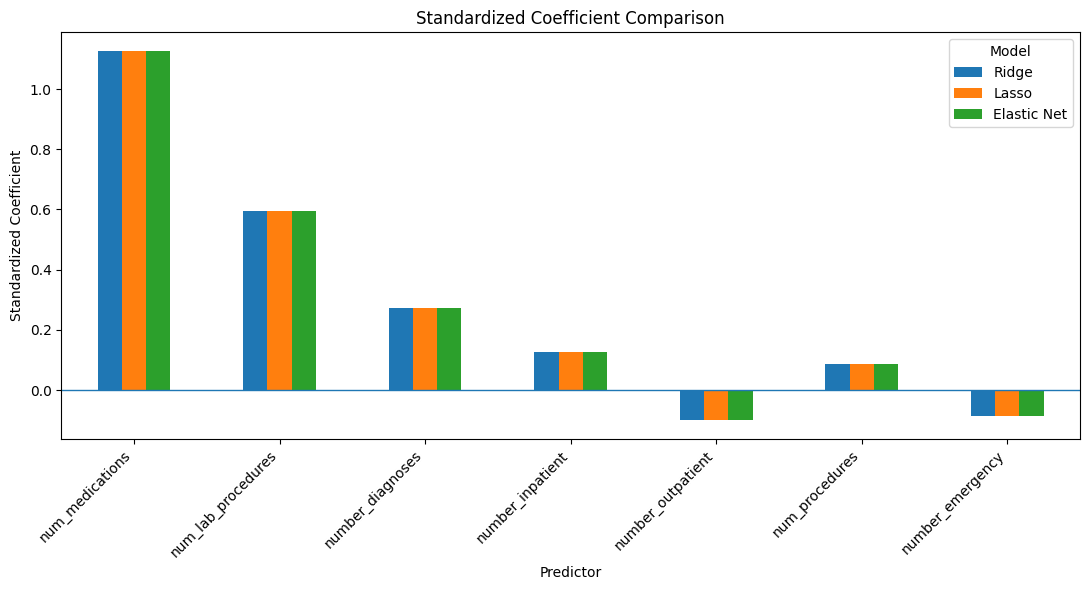

In [36]:
# Prepare coefficient table for plotting
coefficient_plot = coefficient_comparison.set_index('Predictor')

# Create coefficient comparison plot
ax = coefficient_plot.plot(
    kind='bar',
    figsize=(11, 6)
)

plt.title('Standardized Coefficient Comparison')
plt.xlabel('Predictor')
plt.ylabel('Standardized Coefficient')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, linewidth=1)
plt.legend(title='Model')
plt.tight_layout()

plt.show()
plt.close()

### 8B. Analysis

The coefficient visualization demonstrates that the tuned Ridge, Lasso, and Elastic Net models produced nearly identical standardized coefficients. The bars for the three models overlap closely across all seven predictors, indicating that the weak regularization strength (`alpha = 0.001`) resulted in very little coefficient shrinkage.

`num_medications` had the largest positive coefficient, followed by `num_lab_procedures` and `number_diagnoses`. `number_inpatient` and `num_procedures` also had positive coefficients, but with smaller magnitudes. In contrast, the coefficients for `number_outpatient` and `number_emergency` were both negative.

Overall, the visualization supports the numerical findings from Section 8A and shows that weak regularization maintained the models' coefficient structure while yielding nearly identical predictive performance.

# 9. Model Evaluation and Conclusion

## 9A. Final Model Evaluation

### Objective

The objective of this analysis is to summarize the predictive performance of the baseline linear regression, tuned Ridge, tuned Lasso, and tuned Elastic Net models, as well as what was learned from applying regularization to the diabetes hospitalization dataset.

Model performance is evaluated using MAE, RMSE, and R-squared (R²) on the same testing dataset.

In [37]:
# Display final model performance
final_results = pd.DataFrame({
    'Model': [
        'Baseline Linear Regression',
        'Tuned Ridge',
        'Tuned Lasso',
        'Tuned Elastic Net'
    ],
    'MAE': [
        baseline_mae,
        ridge_tuned_mae,
        lasso_tuned_mae,
        elastic_tuned_mae
    ],
    'RMSE': [
        baseline_rmse,
        ridge_tuned_rmse,
        lasso_tuned_rmse,
        elastic_tuned_rmse
    ],
    'R-squared': [
        baseline_r2,
        ridge_tuned_r2,
        lasso_tuned_r2,
        elastic_tuned_r2
    ]
})

print("Final Week 2 Model Evaluation")
display(final_results.round(4))

Final Week 2 Model Evaluation


,Model,MAE,RMSE,R-squared
0,Baseline Linear Regression,1.9251,2.5226,0.2689
1,Tuned Ridge,1.9251,2.5226,0.2689
2,Tuned Lasso,1.9251,2.5226,0.2689
3,Tuned Elastic Net,1.9251,2.5226,0.2689


### 9A. Analysis

The final model evaluation reveals that the baseline linear regression, tuned Ridge, tuned Lasso, and tuned Elastic Net models performed nearly identically on the testing dataset.

All four models had an MAE of about 1.9251 days, an RMSE of 2.5226 days, and an R-squared (R²) of 0.2689. As a result, the regularized models did not show a meaningful improvement in predictive performance over the baseline linear regression model.

The similarity in performance is consistent with the weak regularization strength (`alpha = 0.001`) selected during the tuning procedure. Ridge, Lasso, and Elastic Net applied relatively little coefficient shrinkage at this level while maintaining roughly the same predictive structure as the baseline linear regression model.

The R² value of 0.2689 indicates that the models explained approximately 26.9% of the variation in hospital length of stay. However, substantial variation remained unexplained by the seven predictors included in these models.

## 9B. Final Conclusion

This Week 2 analysis evaluated Ridge, Lasso, and Elastic Net regression for predicting `time_in_hospital` using seven continuous predictors from the diabetes hospitalization dataset.

The initial models demonstrated the importance of choosing an appropriate regularization strength. Ridge regression with `alpha = 1.0` had similar results to the baseline linear regression model. In contrast, Lasso and Elastic Net with `alpha = 1.0` applied stronger coefficient shrinkage, resulting in lower predictive performance.

Testing different regularization strengths revealed that smaller penalties produced better predictive performance. At `alpha = 0.001`, the Ridge, Lasso, and Elastic Net models showed similar MAE, RMSE, and R² values as the baseline linear regression model.

The coefficient analysis also revealed that weak regularization produced nearly identical coefficient estimates across all three regularized models. `num_medications` had the highest positive standardized coefficient, followed by `num_lab_procedures` and `number_diagnoses`.

Regularization did not meaningfully improve predictive performance for this dataset using the seven predictors included in the analysis. However, the analysis highlighted how Ridge, Lasso, and Elastic Net respond differently to increasing regularization strength, emphasizing the importance of tuning regularization parameters rather than depending solely on a single arbitrary alpha value.